In [83]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [84]:
df = pd.read_csv("House_Prices/housing.csv")

In [85]:
print(f'df.head() = \n{df.head()}')
print(f'\ndf.shape = \n{df.shape}')
print(f'\ndf.columns = \n{df.columns.tolist()}')
print(f"\ndf.info() = ")
df.info()

df.head() = 
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

df.shape = 
(20640, 10)

df.columns = 
['longitude', 'latitud

In [86]:
print(df.isnull().sum())
df = df.dropna()
print()
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [87]:
df['ocean_proximity'].unique().tolist()

['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']

In [88]:
df.insert(loc=0, column='intercept', value=1)

df_encoded = pd.get_dummies(df, dtype=int, drop_first=True)

new_columns = [col for col in df_encoded.columns if col != 'median_house_value'] + ['median_house_value']
df_encoded = df_encoded[new_columns]

print(f'df.head() = \n{df.head()}')
print()
print(f'df_encoded.head() = \n{df_encoded.head()}')

df_encoded.to_csv("House_Prices/cleaned_housing_with_intercept.csv", index=False)
print("Successfully generated cleaned_housing_with_intercept.csv")

df_order_2 = pd.get_dummies(df, dtype=int, drop_first=False)

cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

for i in range(len(cols)-5):
    for j in range(i,len(cols)):
        new_col = cols[i] + ' x ' + cols[j]
        df_order_2[new_col] = df_order_2[cols[i]] * df_order_2[cols[j]]

new_order_2_columns = [col for col in df_order_2.columns if col != 'median_house_value'] + ['median_house_value']
df_order_2 = df_order_2[new_order_2_columns]

df_order_2.to_csv("House_Prices/cleaned_order_2_housing_with_intercept.csv", index=False)
print("Successfully generated cleaned_order_2_housing_with_intercept.csv")

df.head() = 
   intercept  longitude  latitude  housing_median_age  total_rooms  \
0          1    -122.23     37.88                41.0        880.0   
1          1    -122.22     37.86                21.0       7099.0   
2          1    -122.24     37.85                52.0       1467.0   
3          1    -122.25     37.85                52.0       1274.0   
4          1    -122.25     37.85                52.0       1627.0   

   total_bedrooms  population  households  median_income  median_house_value  \
0           129.0       322.0       126.0         8.3252            452600.0   
1          1106.0      2401.0      1138.0         8.3014            358500.0   
2           190.0       496.0       177.0         7.2574            352100.0   
3           235.0       558.0       219.0         5.6431            341300.0   
4           280.0       565.0       259.0         3.8462            342200.0   

  ocean_proximity  
0        NEAR BAY  
1        NEAR BAY  
2        NEAR BAY  
3    

In [89]:
print(f'\ndf_encoded.columns = \n{df_encoded.columns.tolist()}')


df_encoded.columns = 
['intercept', 'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'median_house_value']


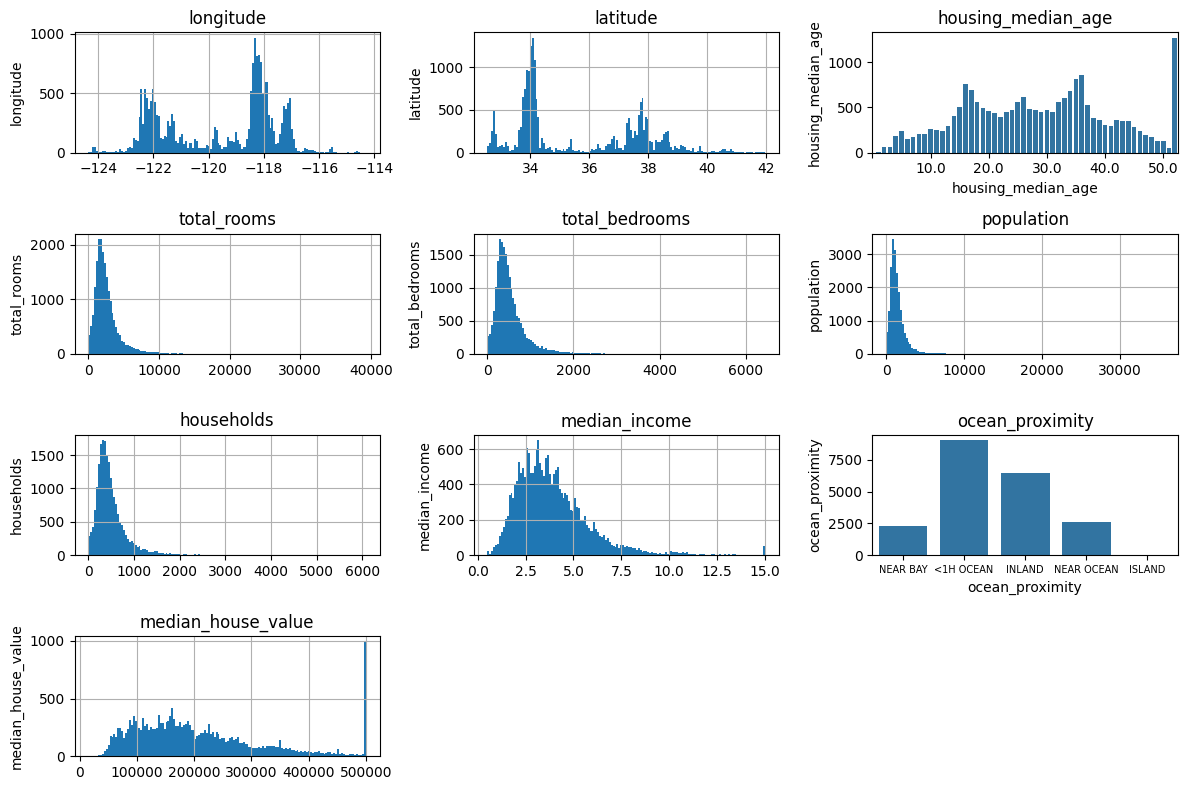

In [90]:
plt.figure(figsize=(12,8))
for i, col in enumerate(['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'median_house_value']):
    plt.subplot(4,3,i+1)
    if col == 'ocean_proximity':
        sns.countplot(x='ocean_proximity', data=df)
        plt.xticks(fontsize=7)
    elif col == 'housing_median_age':
        sns.countplot(x='housing_median_age', data=df)
        plt.xticks(np.arange(-1, 51, step=10))
    else:
        df[col].hist(bins=144)
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('House_Prices/histograms.png',dpi=400,bbox_inches='tight')
plt.show()

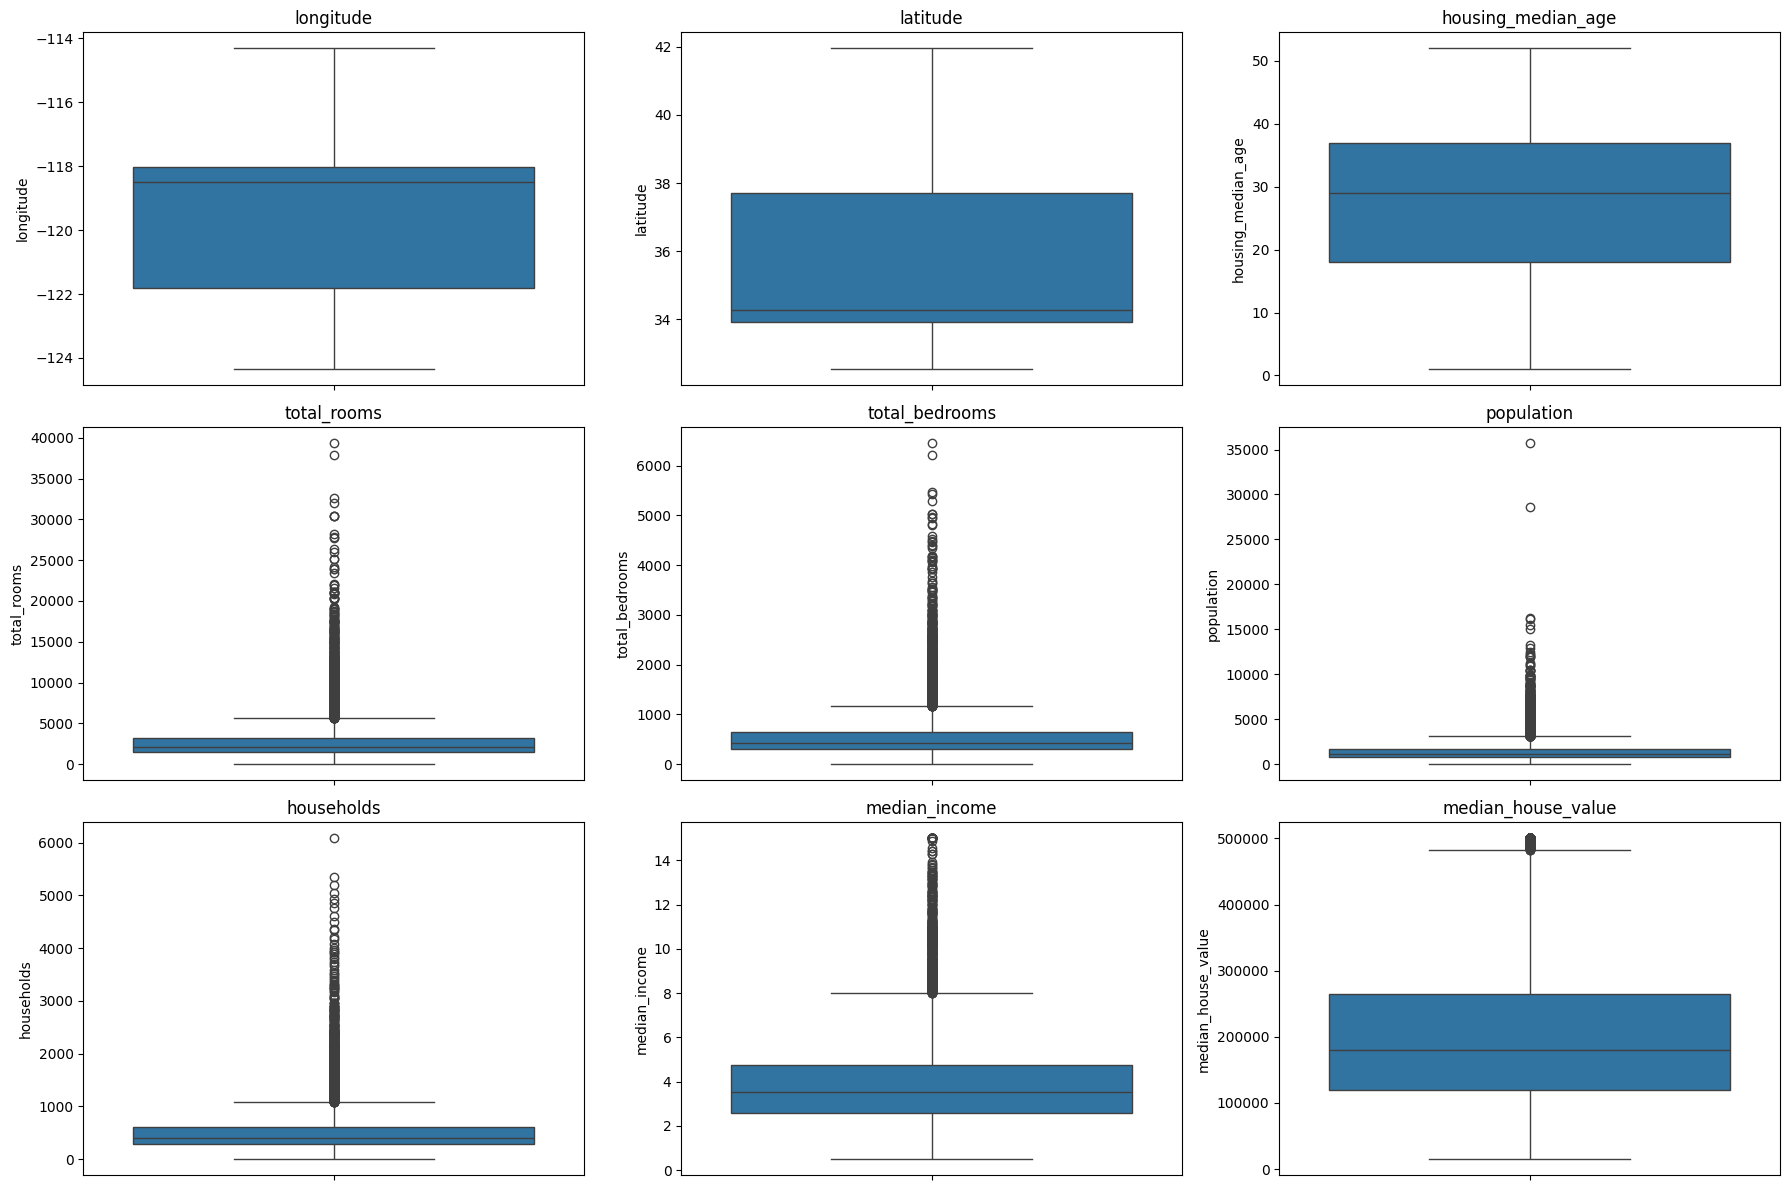

In [91]:
plt.figure(figsize=(18,12))
for i, col in enumerate(['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('House_Prices/boxplots.png',dpi=400,bbox_inches='tight')
plt.show()

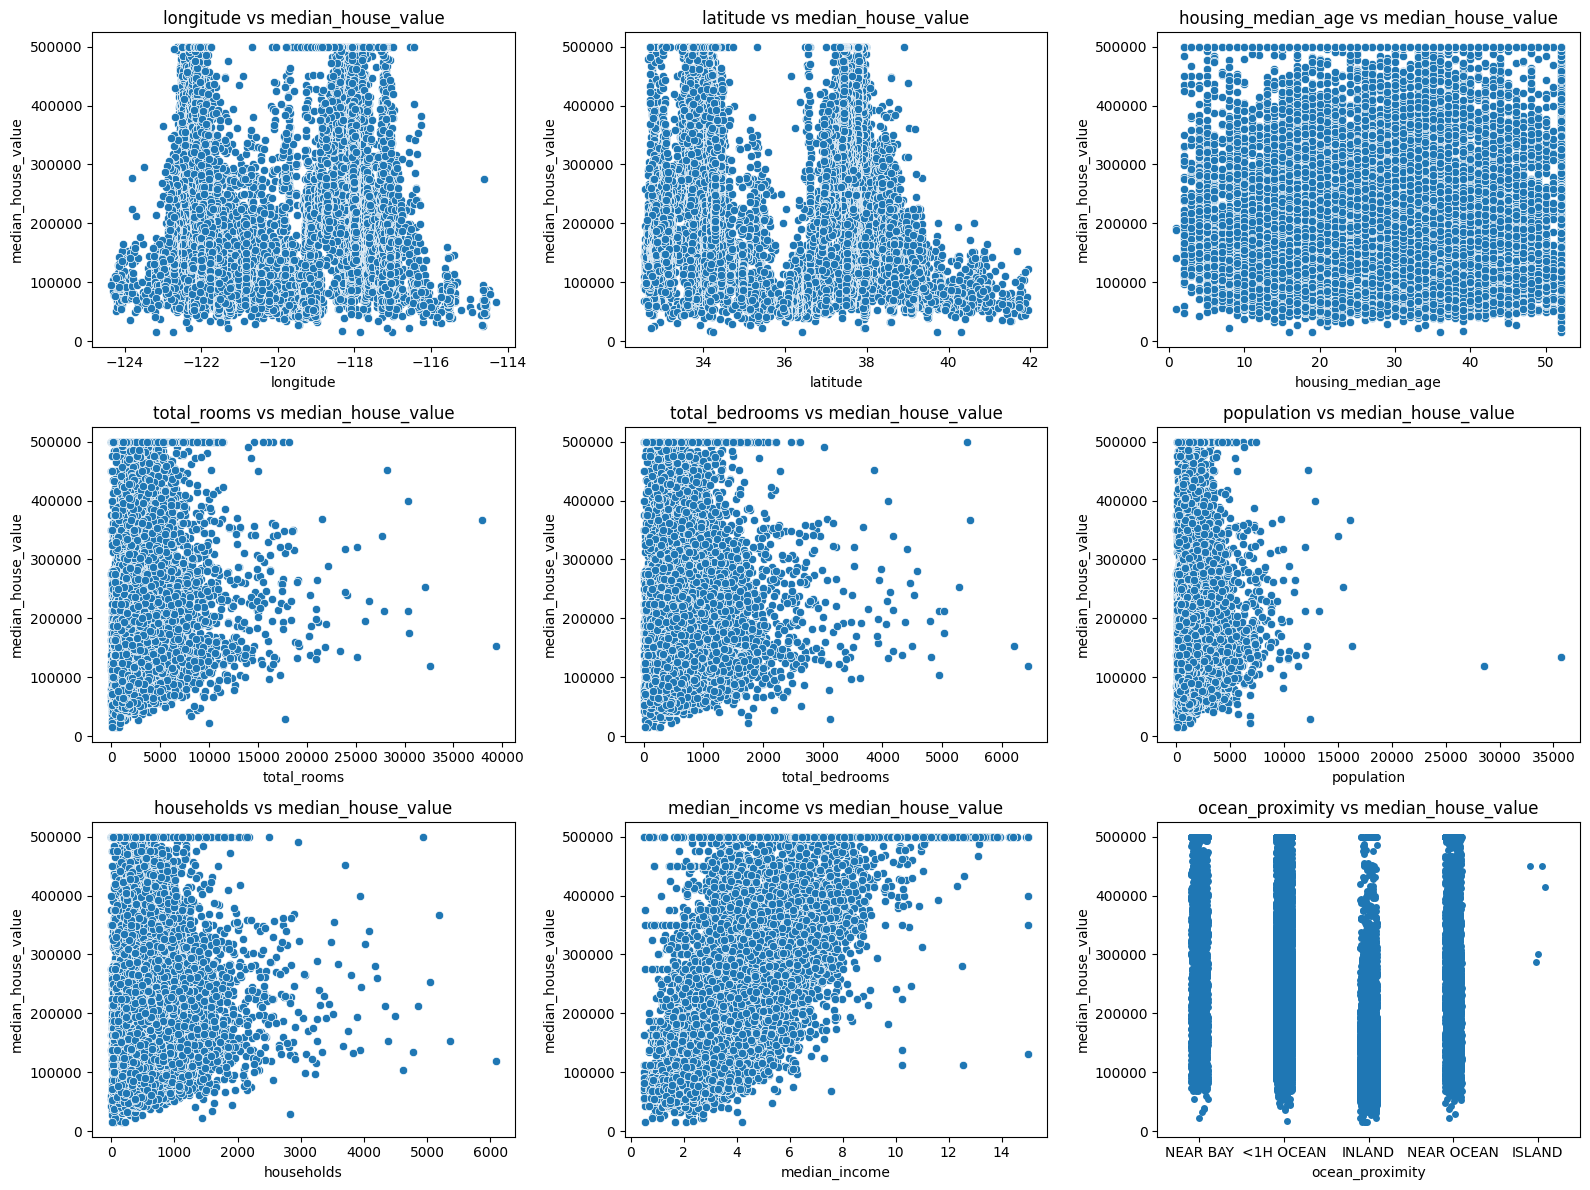

In [92]:
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
cats = ['ocean_proximity']
plt.figure(figsize=(16,12))

for i, col in enumerate(features):
    plt.subplot(3,3,i+1)
    if col not in cats:
        sns.scatterplot(x=df[col], y=df['median_house_value'])
    else:
        sns.stripplot(x=df[col], y=df['median_house_value'])
    plt.title(f"{col} vs median_house_value")

plt.tight_layout()
plt.savefig('House_Prices/scatterplots.png',dpi=400,bbox_inches='tight')
plt.show()

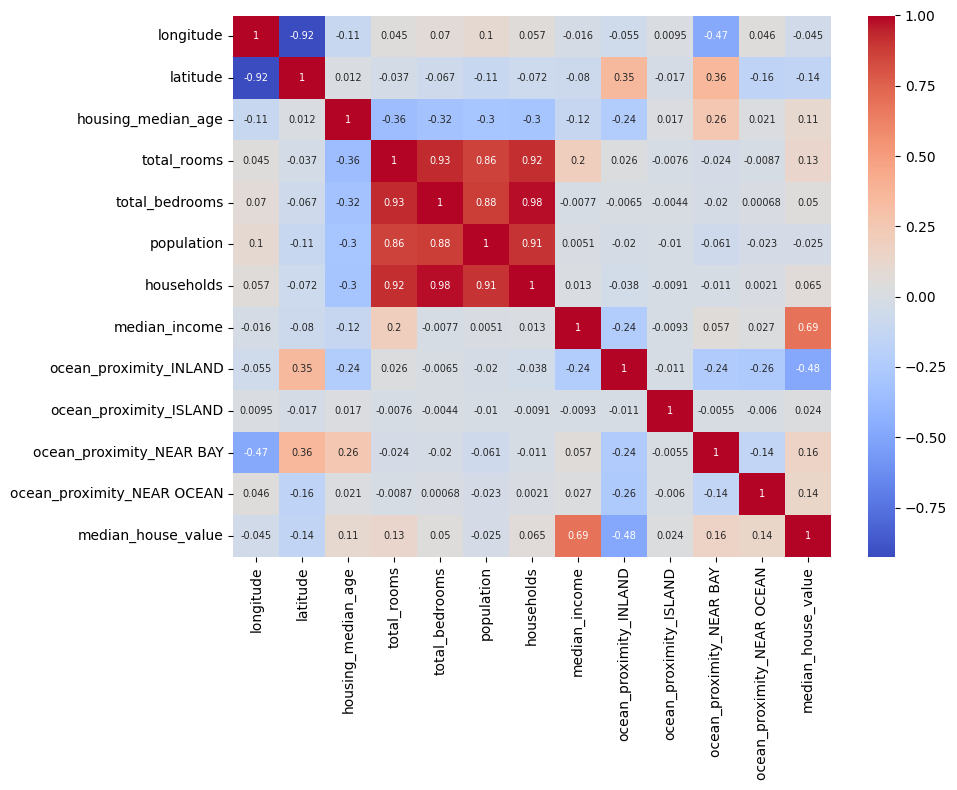

In [93]:
corr = df_encoded.drop('intercept', axis=1).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr , annot = True , cmap = 'coolwarm', annot_kws={"size": 7})

plt.tight_layout()
plt.savefig('House_Prices/correlation_heatmap.png',dpi = 300,bbox_inches='tight')
plt.show()

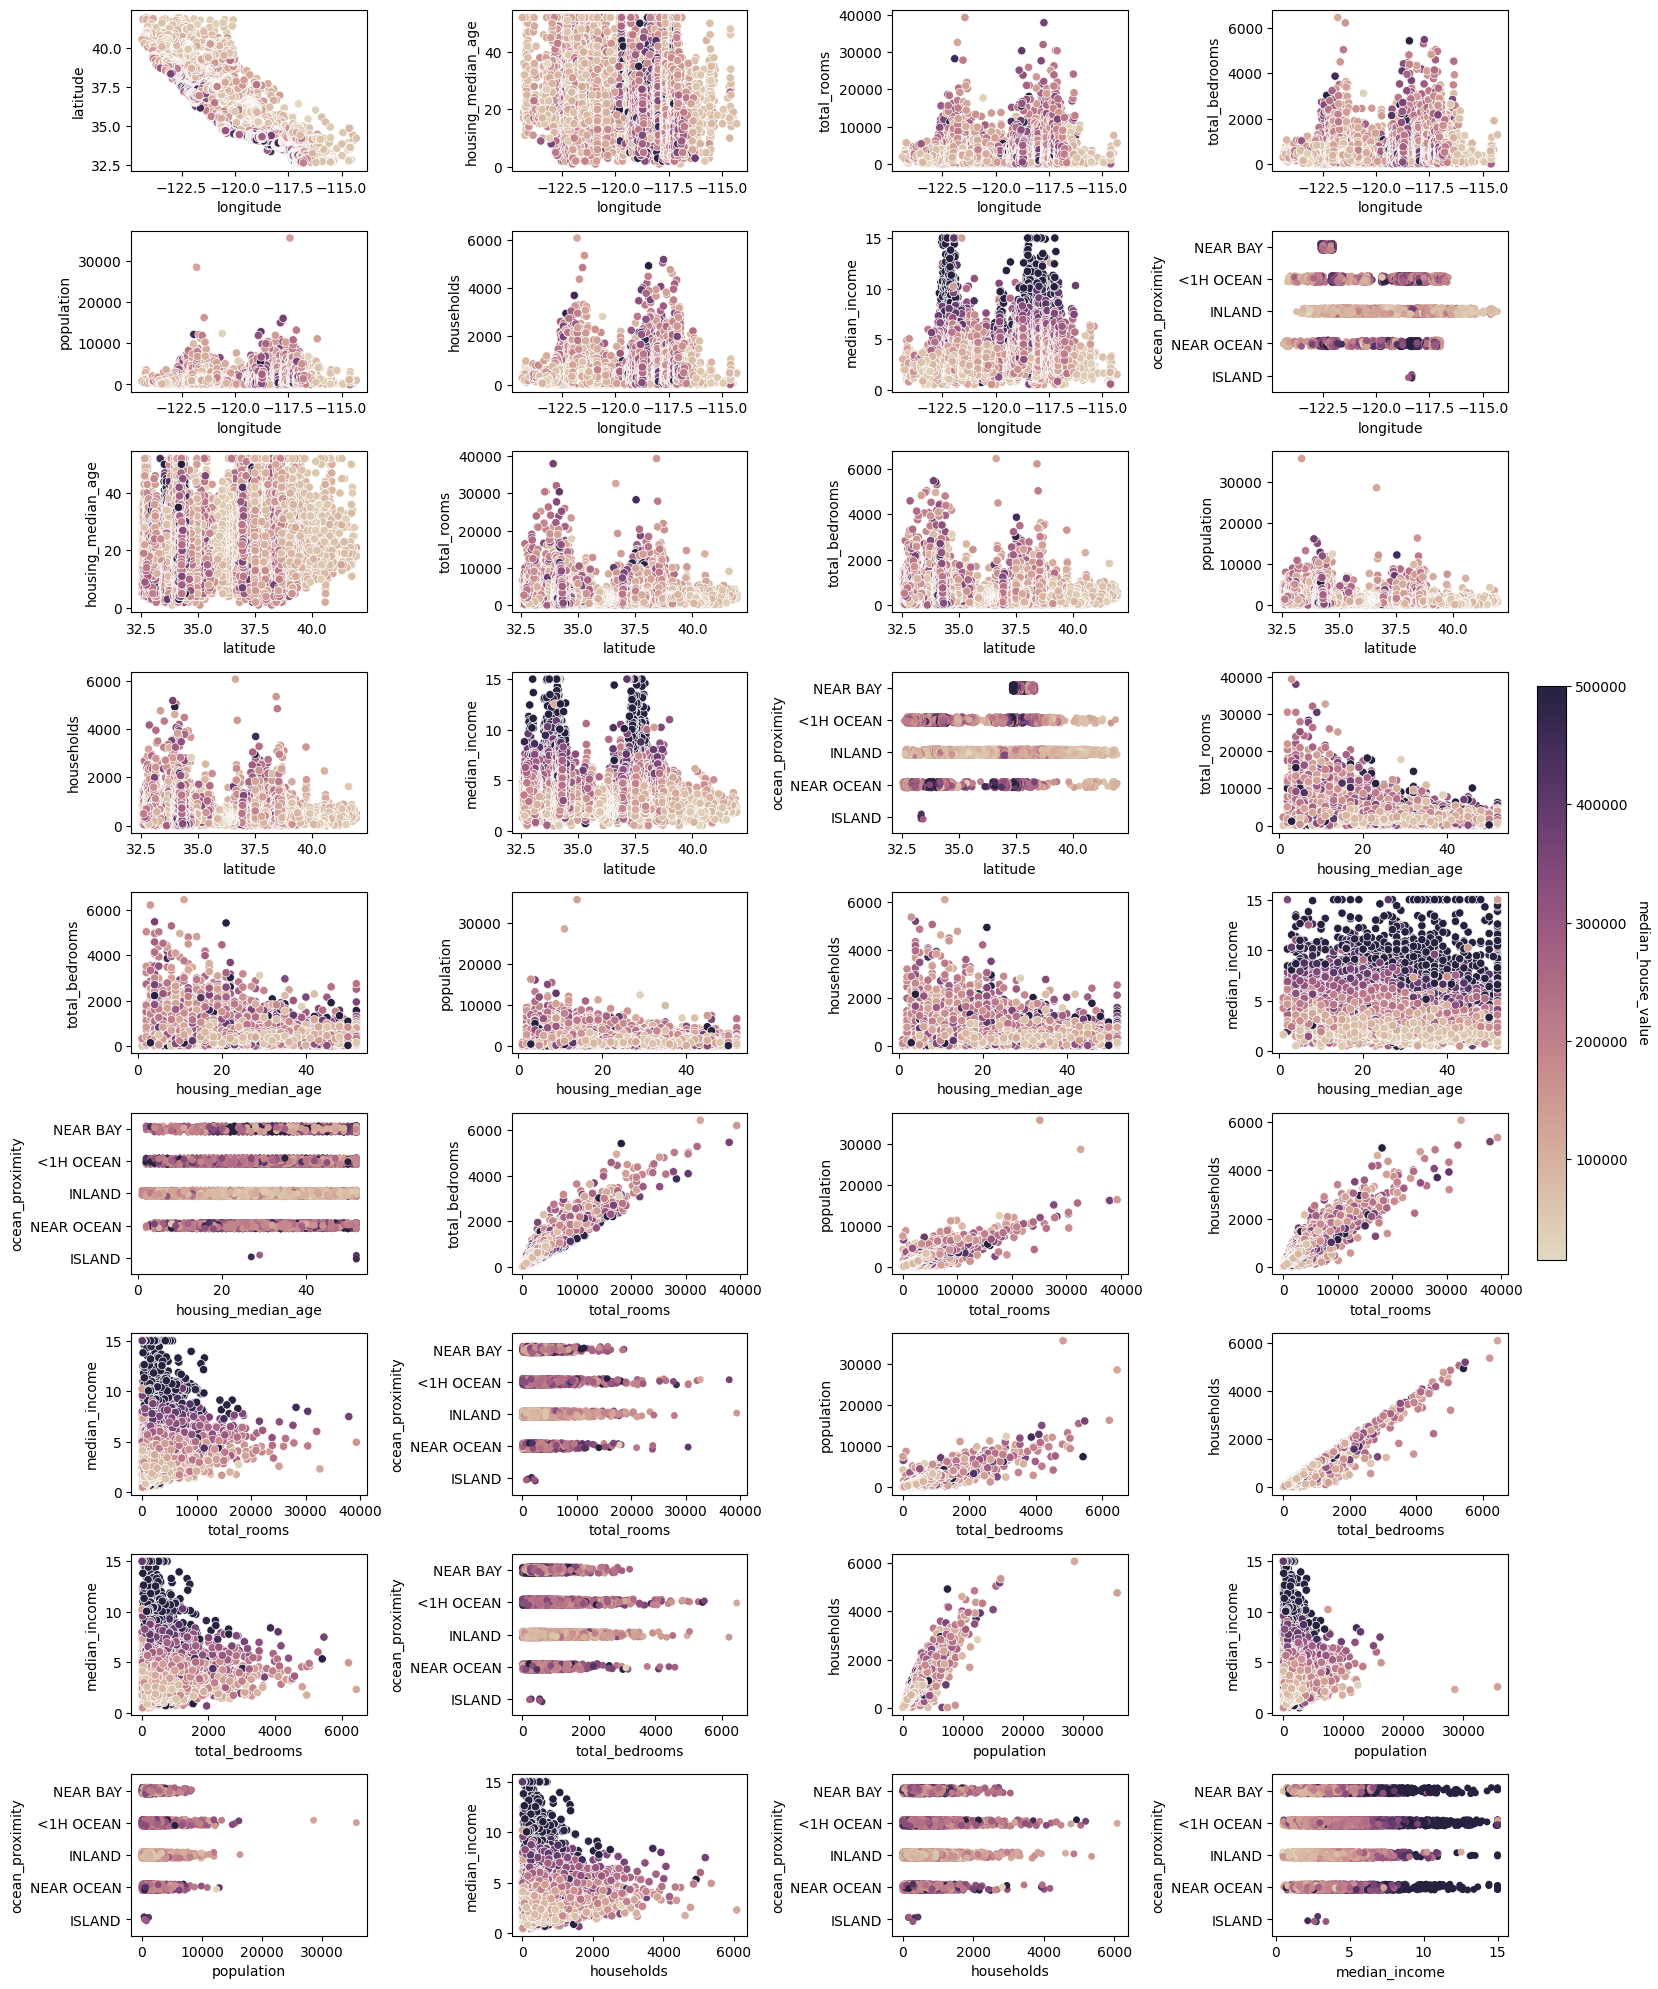

In [94]:
my_norm = colors.Normalize(vmin=df['median_house_value'].min(), vmax=df['median_house_value'].max())
# sns.cubehelix_palette(as_cmap=True)
my_cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)

n = 1
fig = plt.figure(figsize=(16, 20))

for i in range(len(features)-1):
    for j in range(i+1, len(features)):
        plt.subplot(9, 4, n)
        
        if (features[i] not in cats) and (features[j] not in cats):
            sns.scatterplot(x=features[i], y=features[j], hue='median_house_value', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        else:
            sns.stripplot(x=features[i], y=features[j], hue='median_house_value', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        n = n + 1

plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=my_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.02)
cbar.set_label('median_house_value', rotation=270, labelpad=15)

plt.savefig('House_Prices/Hue_Plots.png',dpi=400,bbox_inches='tight')
plt.show()